In [1]:
import os
import shutil
import random
import torch
import torchaudio
import torchaudio.functional as ff
import torchaudio.transforms as tt

In [2]:
ROOT_SRC = '/home/ovistetom/Documents/Databases_Local/EARS/original'
ROOT_DST = '/home/ovistetom/Documents/Databases_Local/EARS/preprocessed'
SAMPLE_RATE = 16000
os.makedirs(ROOT_DST, exist_ok=True)

In [3]:
list_speakers = os.listdir(ROOT_SRC)
num_speakers = len(list_speakers)
random.shuffle(list_speakers)
print(list_speakers[:10])

['p033', 'p095', 'p088', 'p067', 'p045', 'p043', 'p057', 'p031', 'p060', 'p082']


In [4]:
tst_size = int(0.1*num_speakers)
val_size = int(0.1*num_speakers)
trn_size = num_speakers - val_size - tst_size
list_trn = list_speakers[:trn_size]
list_val = list_speakers[trn_size:trn_size+val_size]
list_tst = list_speakers[trn_size+val_size:]

In [5]:
resampler = tt.Resample(orig_freq=48000, new_freq=SAMPLE_RATE)
fader = tt.Fade(fade_in_len=64, fade_out_len=64)

In [6]:
for name_subset, list_subset in zip(['trn', 'val', 'tst'], [list_trn, list_val, list_tst]):

    path_subset_dst = os.path.join(ROOT_DST, name_subset)
    os.makedirs(path_subset_dst, exist_ok=True)

    for name_speaker in list_subset:

        path_speaker_src = os.path.join(ROOT_SRC, name_speaker)
        path_speaker_dst = os.path.join(path_subset_dst, name_speaker)
        os.makedirs(path_speaker_dst, exist_ok=True)

        for i_sample, name_sample in enumerate(os.listdir(path_speaker_src)):

            path_sample_src = os.path.join(path_speaker_src, name_sample)
            path_sample_dst = os.path.join(path_speaker_dst, f"{name_speaker}_{i_sample:03d}.flac")
            waveform, sr = torchaudio.load(uri=path_sample_src, normalize=True, channels_first=True)

            if waveform.size(0) > 1:
                waveform = waveform[0].unsqueeze(0)

            if waveform.mean() > 0.1:
                waveform = waveform - waveform.mean()

            if sr != SAMPLE_RATE:
                assert sr == 48000, f"Sample rate {sr} not supported."
                waveform = resampler(waveform)

            waveform = fader(waveform)
            waveform = waveform / waveform.abs().max()

            torchaudio.save(uri=path_sample_dst, src=waveform, sample_rate=SAMPLE_RATE, channels_first=True)
        break
    break


In [7]:
import matplotlib.pyplot as plt

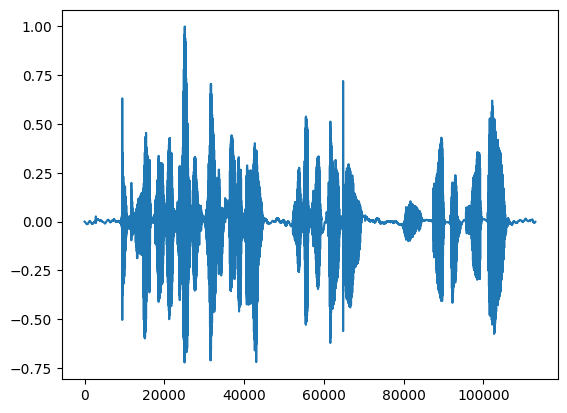

In [8]:
plt.plot(waveform.mT.numpy())